# TP04 MapReduce - Multiplication Matricielle
# Matrice A et B chargées par lignes et colonnes

## Chargement des matrices A et B

In [1]:
import numpy as np
import time
import threading
from multiprocessing import Process, Manager
import matplotlib.pyplot as plt

## Chargement des fichiers lignes et colonnes

In [ ]:
A_data = np.load("A.npz")
B_data = np.load("B.npz")

## Reconstruction de A et B à partir des lignes et colonnes

In [ ]:
%%time
A = np.vstack([A_data[f"row_{i}"] for i in range(len(A_data.files))])
B = np.vstack([B_data[f"col_{j}"] for j in range(len(B_data.files))]).transpose()

CPU times: user 75.3 ms, sys: 94.7 ms, total: 170 ms
Wall time: 170 ms


In [ ]:
# Vérification des dimensions
print(f"Matrice A reconstruite : {A.shape}")
print(f"Matrice B reconstruite : {B.shape}")

Matrice A reconstruite : (100, 10000)
Matrice B reconstruite : (10000, 100)


## Multiplication avec NumPy

In [ ]:
%time C = A @ B
print("Multiplication terminée avec succès.")

CPU times: user 121 ms, sys: 587 µs, total: 122 ms
Wall time: 121 ms
Multiplication terminée avec succès.


In [ ]:
A = np.load("A.npy")
B = np.load("B.npy")

# Affichage des dimensions pour vérification
print(f"Matrice A : {A.shape}")
print(f"Matrice B : {B.shape}")

Matrice A : (100, 10000)
Matrice B : (10000, 100)


In [ ]:
C_numpy = A @ B

## Questions

1. Ecrire un algorithme MapReduce qui calcule le produit matriciel de A et B en **multithreading** dans lequel chaque worker réalise le calcul d’un ou plusieurs $c_{ij}$ en ne chargeant que les lignes et les colonnes nécessaires.

In [2]:

def load_row(file_A, i):
    data = np.load(file_A, allow_pickle=True)
    return data[f'row_{i}']

def load_column(file_B, j):
    data = np.load(file_B, allow_pickle=True)
    return data[f'col_{j}']

def mapper_rows(row_indices, file_A, file_B, nb_cols, output, lock):
    for i in row_indices:
        row = load_row(file_A, i)
        for j in range(nb_cols):
            col = load_column(file_B, j)
            result = np.dot(row, col)
            with lock:
                output[(i, j)] = result


In [5]:
def Produit_mt(file_A, file_B, num_workers=4):
    nb_rows = 100
    nb_cols = 100

    #  Dictionnaire pour stocker les résultats
    output = {}
    lock = threading.Lock()
    threads = []

    rows_per_thread = nb_rows // num_workers
    for t in range(num_workers):
        start = t * rows_per_thread
        end = nb_rows if t == num_workers - 1 else (t + 1) * rows_per_thread
        thread = threading.Thread(
            target=mapper_rows,
            args=(range(start, end), file_A, file_B, nb_cols, output, lock)
        )
        threads.append(thread)
        thread.start()

    for thread in threads:
        thread.join()

    # Assembler la matrice résultante à partir des valeurs calculées
    C = np.zeros((nb_rows, nb_cols))
    for (i, j), value in output.items():
        C[i, j] = value

    return C

In [6]:
%time C_mt = Produit_mt('A.npz','B.npz')

CPU times: user 10.5 s, sys: 2.44 s, total: 12.9 s
Wall time: 11.5 s


2. Ecrire un algorithme MapReduce qui calcule le produit matriciel de A et B en **mutiprocessing** dans lequel chaque worker réalise le calcul d’un ou plusieurs $c_{ij}$ en ne chargeant que les lignes et les colonnes nécessaires.

In [7]:
def worker_compute(tasks, file_A, file_B, output):
    for (i, j) in tasks:
        row = load_row(file_A, i)
        col = load_column(file_B, j)
        output[(i, j)] = np.dot(row, col)

def Produit_mp(file_A, file_B, num_workers=4):
    m = 100
    n = 100

    # Créez une liste de toutes les tâches : une paire (i, j) par élément de C
    tasks = [(i, j) for i in range(m) for j in range(n)]

    # Répartir les tâches entre les travailleurs
    chunk_size = len(tasks) // num_workers
    task_chunks = [tasks[i*chunk_size: (i+1)*chunk_size] for i in range(num_workers)]
    # S'il reste un reste, ajoutez-le au dernier morceau
    remainder = tasks[num_workers*chunk_size:]
    if remainder:
        task_chunks[-1].extend(remainder)

    # Utilisez le Gestionnaire pour créer un dictionnaire partagé pour stocker les résultats
    manager = Manager()
    output = manager.dict()

    processes = []

    # Créez et démarrez un processus pour chaque bloc de tâches (MAP)
    for chunk in task_chunks:
        proc = Process(target=worker_compute, args=(chunk, file_A, file_B, output))
        processes.append(proc)
        proc.start()

    # Attendez que tous les processus soient terminés
    for proc in processes:
        proc.join()

    # Assembler la matrice de produit final C à partir du dictionnaire partagé (REDUCE)
    C = np.zeros((m, n))
    for (i, j), value in output.items():
        C[i, j] = value


    return C

In [8]:
%time C_mp = Produit_mp('A.npz','B.npz')

CPU times: user 91.1 ms, sys: 47.1 ms, total: 138 ms
Wall time: 15.4 s


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can also see here a great disparency between the total time and the wall time, indicating that most of the time is used in overhead operations.
  </p>
</div>


3.Comparer les temps de restitution des différentes implémentations en variant le nombre de workers.

In [9]:
def measure_time(function, A, B):
    """ Calcule les temps de restitution pour plusieurs nombres de workers"""
    worker_counts = [1, 2, 4, 8, 16]
    times = []

    for num_workers in worker_counts:
        tic = time.time()
        C = function(A, B, num_workers)
        toc = time.time()
        duration = toc- tic
        times.append(duration)

    return times

In [10]:
mp_times = measure_time(Produit_mp,'A.npz','B.npz')
mt_times = measure_time(Produit_mt,'A.npz','B.npz')

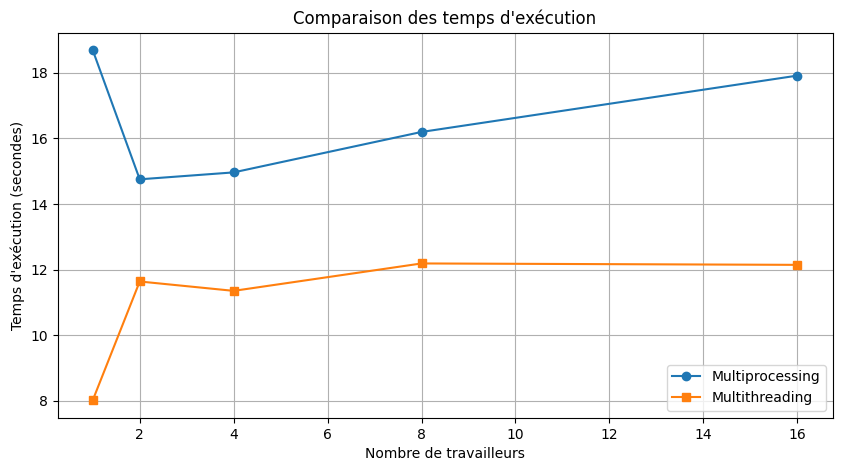

In [12]:
worker_counts = [1, 2, 4, 8, 16]
plt.figure(figsize=(10, 5))
plt.plot(worker_counts, mp_times, label='Multiprocessing', marker='o')
plt.plot(worker_counts, mt_times, label='Multithreading', marker='s')
plt.xlabel('Nombre de travailleurs')
plt.ylabel("Temps d'exécution (secondes)")
plt.title("Comparaison des temps d'exécution")
plt.legend()
plt.grid()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    D'après le graphique précédent, nous pouvons déduire que le nombre de workers a une influence significative sur le temps d'exécution, aussi bien en multithreading qu'en multiprocessing. En comparaison avec le premier exemple, charger uniquement les lignes et colonnes nécessaires a un impact considérable sur les performances.
  </p>
  <p>
    Lorsque nous observons le multithreading, nous remarquons que le temps d'exécution augmente progressivement avec le temps. Cela est une fois de plus causé par l'interpréteur de Python, qui ne peut exécuter qu'un seul thread à la fois en raison de l'effet du GIL.
  </p>
  <p>
    Dans le cas du multiprocessing, nous constatons des temps d'exécution optimaux avec deux et quatre workers, ce qui est objectivement meilleur qu'avec un seul worker. Cependant, augmenter davantage le nombre de workers a entraîné une augmentation du temps d'exécution en raison du Overhead cost.
  </p>
</div>
